<a href="https://colab.research.google.com/github/vyron-arvanitis/pytorch_tutorials/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

In [1]:
what_is_covered = {1: "data (prepare and load)",
                   2: "build model",
                   3: "fit",
                   4: "make predictions and evaluate",
                   5: "save and load the model",
                   6: "putting it all together"}
what_is_covered

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fit',
 4: 'make predictions and evaluate',
 5: 'save and load the model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# PyTorch version
torch.__version__

'2.9.0+cu126'

## 1. Data (prepare and load)


In [3]:
# Create Data using linear regression
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Split data into train, test,  split

In [5]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Visualize data!

In [6]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 7))

  # Plot training data in  lbue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # PLot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Predictions?
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14})



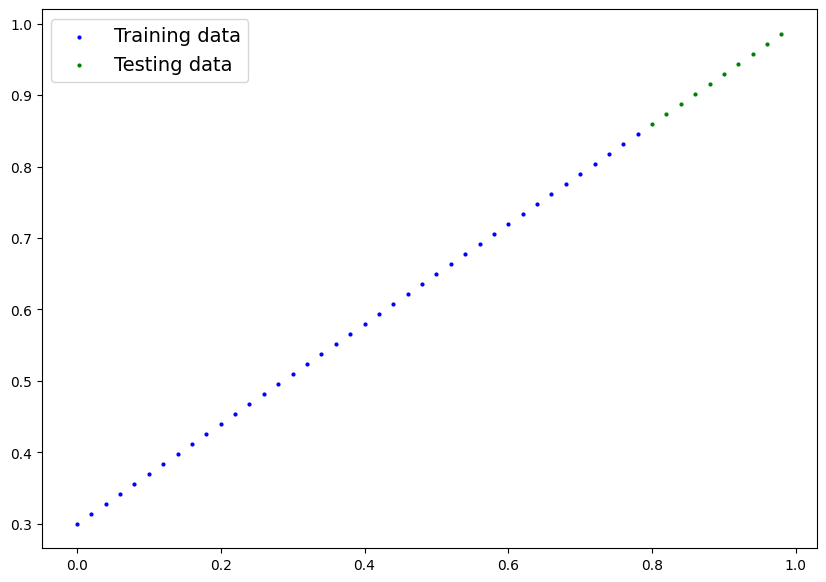

In [7]:
plot_predictions()

## 2. Build Model

In [8]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):

  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # Returns a tensor filled with random numbers from a normal distribution with mean 0 and variance 1
                                           requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn -> all buidling blocks
* torch.nn.Parameter
* torch.nn.Module -> base calss for all neural network modules
* torch.optim -> optimizers of PyTorch
* def forward() -> @abstractmethod of nn.Module

In [9]:
# Create a random seed

torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()
print(model_0.parameters()) # this is a generator-> turn it into a list
print(list(model_0.parameters()))

<generator object Module.parameters at 0x7b8a567f12a0>
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [10]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [11]:
torch.rand(2)

tensor([0.3904, 0.6009])

### Make prediction using `torch.inference_mode()`

In [12]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [13]:
list(model_0.eval().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [15]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

# Simialr result with torch.no_grad(), however inference_modeis prefered
# with torch.no_grad():
#   y_preds = model_0(X_test)

print(f"Our random model got an RMSE of \n {((y_test - y_preds)**2).mean()}")

Our random model got an RMSE of 
 0.24500159919261932


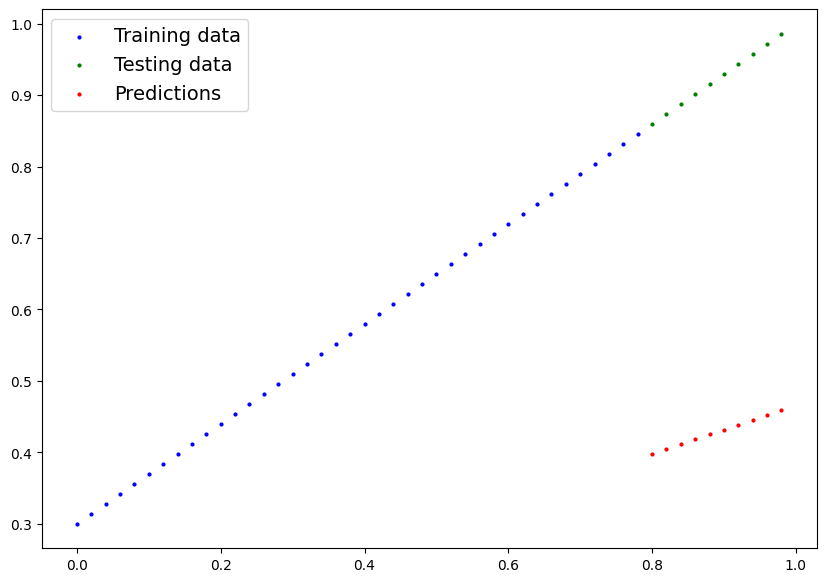

In [16]:
# Visualize the result
plot_predictions(predictions=y_preds)

## Train the model

In [17]:
# Setup the loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

### Build the training loop

0. Loop through the data
1. Forward pass - move forward through the network
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward - move backwards through the network
5. Optimizer step -

In [18]:
torch.manual_seed(42)

# Build the training loop
epochs = 100

# Track different values
epoch_count = []
train_loss_values = []
test_loss_values = []


# 0. Loop through the data
for epoch in range(epochs):
  model_0.train() # train mode in PyTorch sets all aprameters that requrie gradients to require gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimzier zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss wrt the parameters of the model
  loss.backward()

  # 5. Step the otpimizer (perform GD)
  optimizer.step() # by default the optimizer changes will accumulate through the loop so.. we have to zero the, above in step 3.

  ### Testing
  model_0.eval() # needed when you want to predict()
  with torch.inference_mode(): # turnfs off gradient tracking
    # 1. Forward pass
    test_pred = model_0(X_test)
    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    # Print what happens
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")


Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | Test Loss: 0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | Test Loss: 0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | Test Loss: 0.06473556160926819


In [19]:
test_pred

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [20]:
import numpy as np
np.asarray(torch.tensor(train_loss_values).detach().numpy()),test_loss_values

/tmp/ipython-input-619967255.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.asarray(torch.tensor(train_loss_values).detach().numpy()),test_loss_values


(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647)])

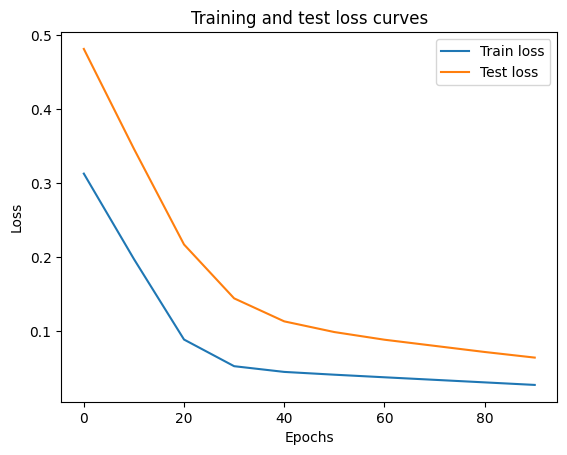

In [21]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).detach().numpy()), label="Train loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).detach().numpy()), label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [23]:
weight, bias

(0.7, 0.3)

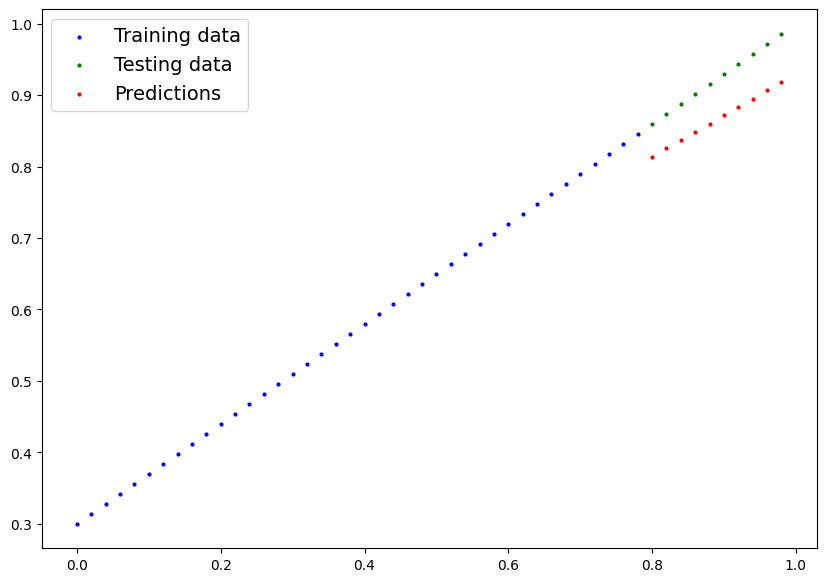

In [24]:
plot_predictions(predictions=test_pred)

## Save a model in PyTorch

1. `torch.save()` - save a PyTorch object in pythons pickle format
2. `torch.load()` - load a saved PyTorch object
3. `torch.nn.Modele.load_state_dict()` - load a models state dict

In [25]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [26]:
from pathlib import Path

# 1. Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict

torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

In [27]:
!ls -l models


total 4
-rw-r--r-- 1 root root 2117 Jan 23 17:07 01_pytorch_workflow_model_0.pth


## Loading a PyTorch model

We saved the model `state_dict()`, rather than the entire model we have to create a new instance of the model and load the saved `state_dict()` into that.

In [28]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [29]:
# To load instanciate a new class
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [30]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [31]:
# Make predictions with loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [32]:
# Compare loaded model preds with originla model preds
loaded_model_preds == test_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting it all together



In [33]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.9.0+cu126'

In [35]:
!nvidia-smi

Fri Jan 23 17:07:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Create device-agnostic code!

In [34]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using devices {device}")

 Using devices cuda


### Data

In [36]:
# Create data using linear regression formula y= w * X + b
weight = 0.6
bias = 0.1

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y ( features and labels)

X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsueeze errors will pop up
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1120],
         [0.1240],
         [0.1360],
         [0.1480],
         [0.1600],
         [0.1720],
         [0.1840],
         [0.1960],
         [0.2080]]))

In [41]:
X_train.shape

torch.Size([40, 1])

In [37]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

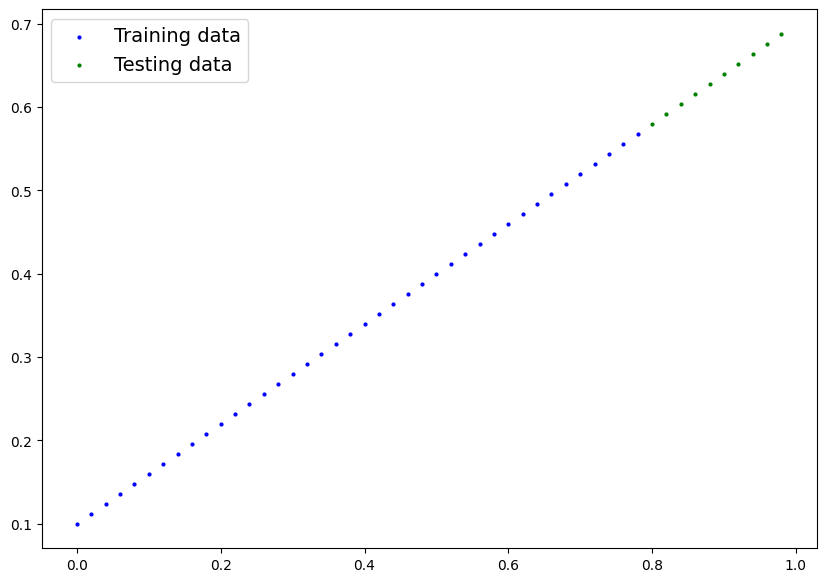

In [38]:
# Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

## Build a Linear model

In [101]:
# Create a linear model by subclassing nn.Module
in_feature = X_train.shape[1]
class LinearModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=in_feature,
                                  out_features=in_feature,
                                  device=device,
                                  dtype=torch.float
                                  )
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1, model_1.state_dict()

(LinearRegressionModel(),
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))

In [102]:
# Check the model current device
# model_1.parameters().device # -> this is a generator therefore you need to get an iterable therefore do next()!
print(type(model_1.parameters()))
print(type(next(model_1.parameters())))
next(model_1.parameters()).device


<class 'generator'>
<class 'torch.nn.parameter.Parameter'>


device(type='cpu')

In [103]:
# Set the model to use the device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### Trainig

We need:


1.   Loss function
2.   Optimizer
3.   Training loop
4.   Testing loop



In [104]:
# Setup the loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.Adam(params=model_1.parameters(),
                            lr=0.01)

In [105]:
# Training loop

torch.manual_seed(64)
epochs = 25
train_loss_values = []
test_loss_values = []

# Put data on the target device!!!!!!
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Loop through the data

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Compute loss
  train_loss_value = loss_fn(y_pred, y_train)
  train_loss_values.append(train_loss_value.item())

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation
  train_loss_value.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss_value = loss_fn(test_pred, y_test)
    test_loss_values.append(test_loss_value.item())

  # if train_loss_value[epoch] < train

  # Verbose
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Train loss: {train_loss_value} | Test loss: {test_loss_value}")




Epoch: 0 | Train loss: 0.078574538230896 | Test loss: 0.18663620948791504
Epoch: 10 | Train loss: 0.042549699544906616 | Test loss: 0.04653750732541084
Epoch: 20 | Train loss: 0.02643795683979988 | Test loss: 0.06775831431150436


In [106]:
model_1.state_dict()

OrderedDict([('weights', tensor([0.4992], device='cuda:0')),
             ('bias', tensor([0.1324], device='cuda:0'))])

In [107]:
weight, bias

(0.6, 0.1)

In [112]:
len([_ for _ in range(epochs)]), len(train_loss_values), range(len(train_loss_values)), range(len(test_loss_values))

(25, 25, range(0, 25), range(0, 25))

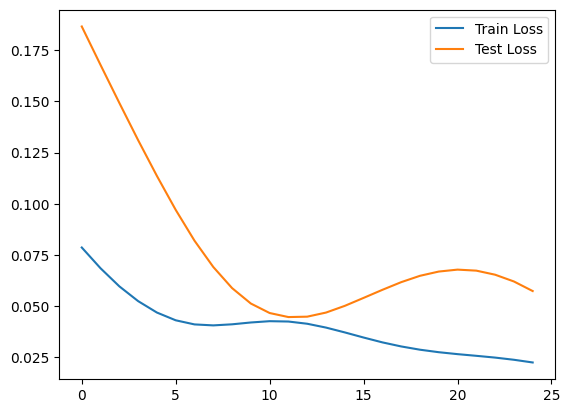

In [116]:
plt.plot([_ for _ in range(epochs)], np.array(torch.tensor(train_loss_values).detach().cpu()), label="Train Loss" )
plt.plot(range(len(test_loss_values)), test_loss_values , label="Test Loss")
plt.legend()

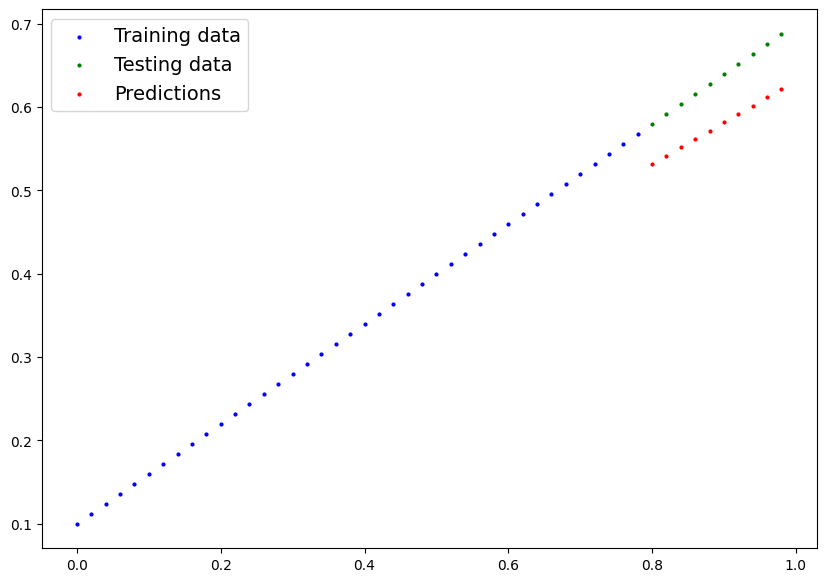

In [123]:
X_train_cpu = X_train.detach().cpu()
y_train_cpu = y_train.detach().cpu()
X_test_cpu  = X_test.detach().cpu()
y_test_cpu  = y_test.detach().cpu()

pred_cpu = test_pred.detach().cpu()

plot_predictions(X_train_cpu, y_train_cpu, X_test_cpu, y_test_cpu, predictions=pred_cpu)


### Save and load the model